# Multi-Class Vehicle Detection
This notebook computes dataset statistics and visualizations for a multi-class vehicle detection task using YOLO-format labels (class x_center y_center width height, normalized).

## Phase 1 — Data Loading & Preprocessing

In [34]:
import os
import re
import collections
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Deep learning / CV libraries
import torch
import torchvision
import cv2
import albumentations as A
from pycocotools.coco import COCO
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import yaml
import numpy as np
from PIL import Image

sns.set(style="whitegrid")


In [35]:
# Phase 1 — Data Loading & Preprocessing (Imports)
import os
import shutil
from pathlib import Path
import random
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from albumentations.pytorch import ToTensorV2
import albumentations as A
import cv2
import torch
import collections
import numpy as np
import matplotlib.patches as patches

print('✓ Phase 1 imports loaded successfully')

✓ Phase 1 imports loaded successfully


In [36]:
# 1.1 — carve_test_split
def _read_yolo_classes(label_path):
    classes = []
    if not label_path.exists():
        return classes

    try:
        with open(label_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                try:
                    classes.append(int(float(parts[0])))
                except Exception:
                    continue
    except Exception:
        return classes

    return classes


def _build_stratify_keys(image_paths, label_dir):
    label_dir = Path(label_dir)
    class_counts = collections.Counter()
    per_image_classes = {}

    for img_path in image_paths:
        label_path = label_dir / (img_path.stem + '.txt')
        classes = sorted(set(_read_yolo_classes(label_path)))
        per_image_classes[img_path] = classes
        for cls in classes:
            class_counts[cls] += 1

    strat_keys = []
    for img_path in image_paths:
        classes = per_image_classes[img_path]
        if not classes:
            strat_keys.append('background')
            continue

        rarest_class = min(classes, key=lambda cls: (class_counts[cls], cls))
        strat_keys.append(f'class_{rarest_class}')

    return strat_keys, class_counts


def carve_test_split(train_image_dir, train_label_dir,
                     test_image_dir, test_label_dir,
                     split_ratio=0.05, seed=42):
    train_image_dir = Path(train_image_dir)
    train_label_dir = Path(train_label_dir)
    test_image_dir = Path(test_image_dir)
    test_label_dir = Path(test_label_dir)

    image_paths = sorted([p for p in train_image_dir.glob('*') if p.suffix.lower() in ('.jpg','.jpeg','.png')])
    print(f'  Found {len(image_paths)} images in training set')

    strat_keys, class_counts = _build_stratify_keys(image_paths, train_label_dir)
    print(f'  Class presence counts: {dict(class_counts)}')

    try:
        train_paths, test_paths = train_test_split(
            image_paths,
            test_size=split_ratio,
            stratify=strat_keys,
            random_state=seed
        )
        print(f'  Stratified split: {len(train_paths)} train, {len(test_paths)} test')
    except Exception as exc:
        train_paths, test_paths = train_test_split(
            image_paths,
            test_size=split_ratio,
            random_state=seed
        )
        print(f'  Random split (fallback: {exc}): {len(train_paths)} train, {len(test_paths)} test')

    test_image_dir.mkdir(parents=True, exist_ok=True)
    test_label_dir.mkdir(parents=True, exist_ok=True)

    for p in test_paths:
        src_img = p
        dst_img = test_image_dir / p.name
        if src_img.exists():
            shutil.copy2(str(src_img), str(dst_img))

        src_lbl = train_label_dir / (p.stem + '.txt')
        dst_lbl = test_label_dir / (p.stem + '.txt')
        if src_lbl.exists():
            shutil.copy2(str(src_lbl), str(dst_lbl))
        else:
            dst_lbl.write_text('', encoding='utf-8')

    print(f'  Copied {len(test_paths)} files to test set')
    return [str(x) for x in train_paths], [str(x) for x in test_paths]

print('✓ carve_test_split function defined')

✓ carve_test_split function defined


In [37]:
# 1.2 — VehicleDataset class
class VehicleDataset(Dataset):
    """
    Loads image + YOLO-format label pairs.
    Returns:
        image  : FloatTensor [3, H, W], normalized to [0,1] (or ToTensorV2 output)
        target : dict with keys 'boxes' (N,4) and 'labels' (N,) where boxes are in yolo-format
    """
    def __init__(self, image_dir, label_dir, img_size=640, transforms=None, mode='train'):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.img_size = img_size
        self.transforms = transforms
        self.mode = mode

        self.images = sorted([p for p in self.image_dir.glob('*') if p.suffix.lower() in ('.jpg','.jpeg','.png')])
        print(f'  VehicleDataset: loaded {len(self.images)} images from {image_dir}')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = cv2.imread(str(img_path))
        if img is None:
            # return an empty image and empty target
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # load labels
        lbl_path = self.label_dir / (img_path.stem + '.txt')
        boxes = []
        labels = []
        if lbl_path.exists():
            try:
                with open(lbl_path, 'r', encoding='utf-8') as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5:
                            continue
                        try:
                            cls = int(float(parts[0]))
                            cx, cy, bw, bh = map(float, parts[1:5])
                        except Exception:
                            continue
                        boxes.append([cx, cy, bw, bh])
                        labels.append(cls)
            except Exception:
                pass

        # albumentations expects boxes list and a parallel list of labels
        if self.transforms is not None:
            # albumentations requires label field name; we use 'class_labels'
            try:
                transformed = self.transforms(image=img, bboxes=boxes, class_labels=labels)
                img = transformed['image']
                boxes = transformed.get('bboxes', [])
                labels = transformed.get('class_labels', [])
            except Exception:
                # if transform fails, continue with raw data
                pass

        # normalize labels to plain ints before tensor conversion
        labels = [int(float(label)) for label in labels]

        # convert image to tensor if it's still a numpy array
        if isinstance(img, np.ndarray):
            # if ToTensorV2 wasn't used, convert manually
            img = torch.from_numpy(img).permute(2,0,1).float() / 255.0

        target = {}
        if len(boxes) > 0:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.long)
        else:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.long)

        target['boxes'] = boxes
        target['labels'] = labels
        target['image_id'] = torch.tensor([idx])

        return img, target

    @staticmethod
    def collate_fn(batch):
        images = [b[0] for b in batch]
        targets = [b[1] for b in batch]
        images = torch.stack(images, dim=0)
        return images, targets

print('✓ VehicleDataset class defined')

✓ VehicleDataset class defined


In [38]:
# 1.3 — Augmentations (train & val transforms)
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transforms = A.Compose([
    A.RandomResizedCrop(size=(640, 640), scale=(0.5, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    A.GaussNoise(p=0.2),
    A.Blur(blur_limit=3, p=0.1),
    A.RandomRain(p=0.1),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], clip=True, filter_invalid_bboxes=True))

val_transforms = A.Compose([
    A.LongestMaxSize(max_size=640),
    A.PadIfNeeded(640, 640, border_mode=cv2.BORDER_CONSTANT, fill=114),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], clip=True, filter_invalid_bboxes=True))

# Disk export transforms keep images in uint8 form so they can be saved back to JPEG/PNG.
disk_train_transforms = A.Compose([
    A.RandomResizedCrop(size=(640, 640), scale=(0.5, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    A.GaussNoise(p=0.2),
    A.Blur(blur_limit=3, p=0.1),
    A.RandomRain(p=0.1)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], clip=True, filter_invalid_bboxes=True))

disk_eval_transforms = A.Compose([
    A.LongestMaxSize(max_size=640),
    A.PadIfNeeded(640, 640, border_mode=cv2.BORDER_CONSTANT, fill=114)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'], clip=True, filter_invalid_bboxes=True))

print('✓ train_transforms created')
print('✓ val_transforms created')
print('✓ disk_train_transforms created')
print('✓ disk_eval_transforms created')

✓ train_transforms created
✓ val_transforms created
✓ disk_train_transforms created
✓ disk_eval_transforms created


In [39]:
# 1.4 — Materialize augmented dataset on disk
def _read_yolo_annotation(label_path):
    boxes = []
    class_labels = []
    label_path = Path(label_path)
    if not label_path.exists():
        return boxes, class_labels

    try:
        with open(label_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                try:
                    cls = int(float(parts[0]))
                    cx, cy, bw, bh = map(float, parts[1:5])
                except Exception:
                    continue
                boxes.append([cx, cy, bw, bh])
                class_labels.append(cls)
    except Exception:
        return [], []

    return boxes, class_labels


def _write_yolo_annotation(label_path, boxes, class_labels):
    label_path = Path(label_path)
    label_path.parent.mkdir(parents=True, exist_ok=True)
    with open(label_path, 'w', encoding='utf-8') as f:
        for cls, box in zip(class_labels, boxes):
            cx, cy, bw, bh = box
            f.write(f'{int(cls)} {float(cx):.6f} {float(cy):.6f} {float(bw):.6f} {float(bh):.6f}\n')


def _ensure_rgb_uint8(image):
    if isinstance(image, torch.Tensor):
        image = image.detach().cpu()
        if image.ndim == 3:
            image = image.permute(1, 2, 0).numpy()
    if image.dtype != np.uint8:
        if np.issubdtype(image.dtype, np.floating) and image.max() <= 1.0 and image.min() >= 0.0:
            image = image * 255.0
        image = np.clip(image, 0, 255).astype(np.uint8)
    return image


def _export_split(image_paths, source_label_dir, output_image_dir, output_label_dir, transform):
    output_image_dir = Path(output_image_dir)
    output_label_dir = Path(output_label_dir)
    output_image_dir.mkdir(parents=True, exist_ok=True)
    output_label_dir.mkdir(parents=True, exist_ok=True)

    for src_img_path in sorted(image_paths):
        image = cv2.imread(str(src_img_path))
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label_path = Path(source_label_dir) / f'{src_img_path.stem}.txt'
        boxes, class_labels = _read_yolo_annotation(label_path)
        transformed = transform(image=image, bboxes=boxes, class_labels=class_labels)
        out_image = _ensure_rgb_uint8(transformed['image'])
        out_boxes = transformed.get('bboxes', [])
        out_labels = transformed.get('class_labels', [])
        out_image_path = output_image_dir / src_img_path.name
        cv2.imwrite(str(out_image_path), cv2.cvtColor(out_image, cv2.COLOR_RGB2BGR))
        _write_yolo_annotation(output_label_dir / f'{src_img_path.stem}.txt', out_boxes, out_labels)


def build_augmented_dataset(source_root='data', output_root='augmented dataset', split_ratio=0.05, seed=42):
    source_root = Path(source_root)
    output_root = Path(output_root)

    train_image_dir = source_root / 'train' / 'images'
    train_label_dir = source_root / 'train' / 'labels'
    val_image_dir = source_root / 'val' / 'images'
    val_label_dir = source_root / 'val' / 'labels'

    train_out_images = output_root / 'train' / 'images'
    train_out_labels = output_root / 'train' / 'labels'
    val_out_images = output_root / 'val' / 'images'
    val_out_labels = output_root / 'val' / 'labels'
    test_out_images = output_root / 'test' / 'images'
    test_out_labels = output_root / 'test' / 'labels'

    train_paths, test_paths = carve_test_split(
        train_image_dir,
        train_label_dir,
        test_out_images,
        test_out_labels,
        split_ratio=split_ratio,
        seed=seed,
    )
    train_paths = [Path(p) for p in train_paths]
    test_paths = [Path(p) for p in test_paths]

    _export_split(train_paths, train_label_dir, train_out_images, train_out_labels, disk_train_transforms)
    val_paths = sorted([p for p in val_image_dir.glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])
    _export_split(val_paths, val_label_dir, val_out_images, val_out_labels, disk_eval_transforms)

    print(f'✓ Augmented dataset written to: {output_root}')
    print(f'  train: {len(train_paths)} images')
    print(f'  test : {len(test_paths)} images')
    print(f'  val  : {len(val_paths)} images')
    return output_root


DATA_ROOT = Path('data')
OUTPUT_ROOT = Path('augmented dataset')
# build_augmented_dataset(DATA_ROOT, OUTPUT_ROOT, split_ratio=0.10, seed=42)

# Phase 2 — Dataset Analysis
Count the number of images in the augmented train, val, and test splits, summarize class occurrences, and visualize random samples from the new dataset.

In [40]:
from pathlib import Path
from collections import Counter
import random

dataset_root = Path('augmentedDataset')
splits = {
    'train': dataset_root / 'train' / 'images',
    'val': dataset_root / 'val' / 'images',
    'test': dataset_root / 'test' / 'images',
}
label_splits = {name: Path(str(path).replace('/images', '/labels')) for name, path in splits.items()}

def count_images(image_dir):
    return len([p for p in image_dir.glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])

def count_classes(label_dir):
    counts = Counter()
    for label_path in label_dir.glob('*.txt'):
        for line in label_path.read_text(encoding='utf-8').splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            try:
                counts[int(float(parts[0]))] += 1
            except Exception:
                continue
    return counts

image_counts = {split: count_images(path) for split, path in splits.items()}
class_counts = {split: count_classes(path) for split, path in label_splits.items()}

print('Augmented Dataset Image Counts')
for split in ['train', 'val', 'test']:
    print(f"  {split}: {image_counts[split]}")

print('\nClass Counts by Split')
for split in ['train', 'val', 'test']:
    print(f"  {split}: {dict(sorted(class_counts[split].items()))}")

Augmented Dataset Image Counts
  train: 7066
  val: 982
  test: 786

Class Counts by Split
  train: {0: 1052, 1: 47517, 2: 4529, 3: 5004}
  val: {0: 207, 1: 9470, 2: 954, 3: 984}
  test: {0: 125, 1: 5725, 2: 551, 3: 600}


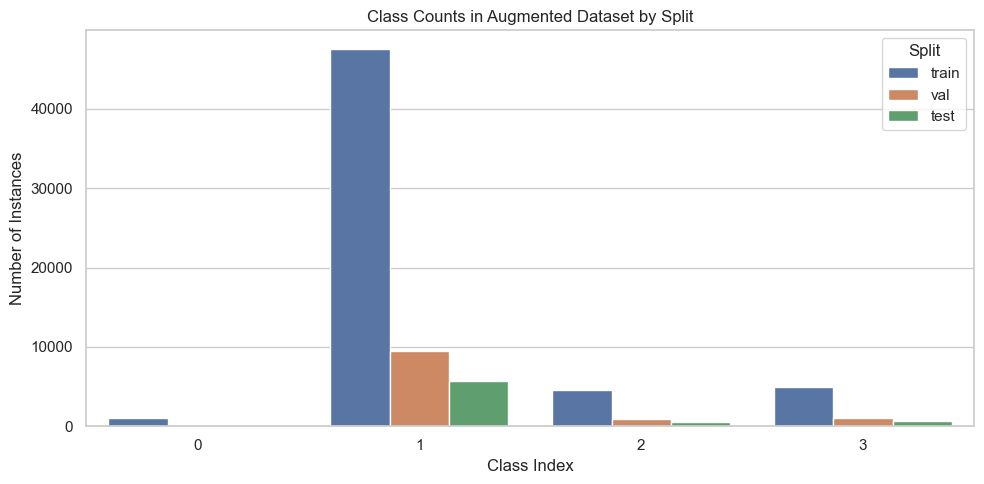

/var/folders/v6/frwp0yjs06j_wm3461r0j6rr0000gp/T/ipykernel_29039/809890121.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(split_totals.keys()), y=list(split_totals.values()), palette='viridis')


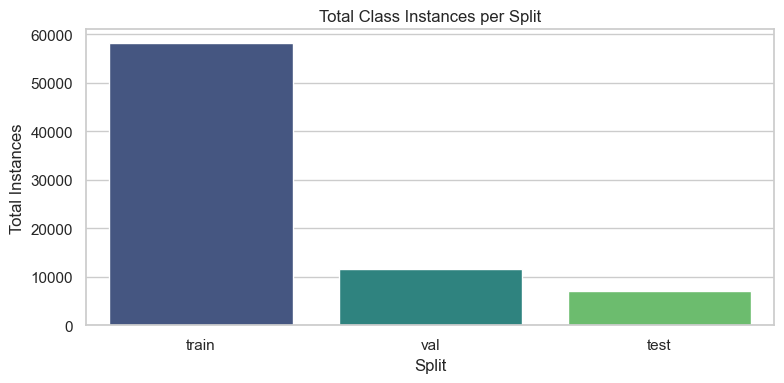

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

split_totals = {split: sum(counter.values()) for split, counter in class_counts.items()}
all_classes = sorted({cls for counter in class_counts.values() for cls in counter.keys()})

plot_rows = []
for split in ['train', 'val', 'test']:
    for cls in all_classes:
        plot_rows.append({'split': split, 'class': cls, 'count': class_counts[split].get(cls, 0)})

plot_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='class', y='count', hue='split')
plt.title('Class Counts in Augmented Dataset by Split')
plt.xlabel('Class Index')
plt.ylabel('Number of Instances')
plt.legend(title='Split')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(x=list(split_totals.keys()), y=list(split_totals.values()), palette='viridis')
plt.title('Total Class Instances per Split')
plt.xlabel('Split')
plt.ylabel('Total Instances')
plt.tight_layout()
plt.show()

Displaying 6 random train images with bounding boxes:


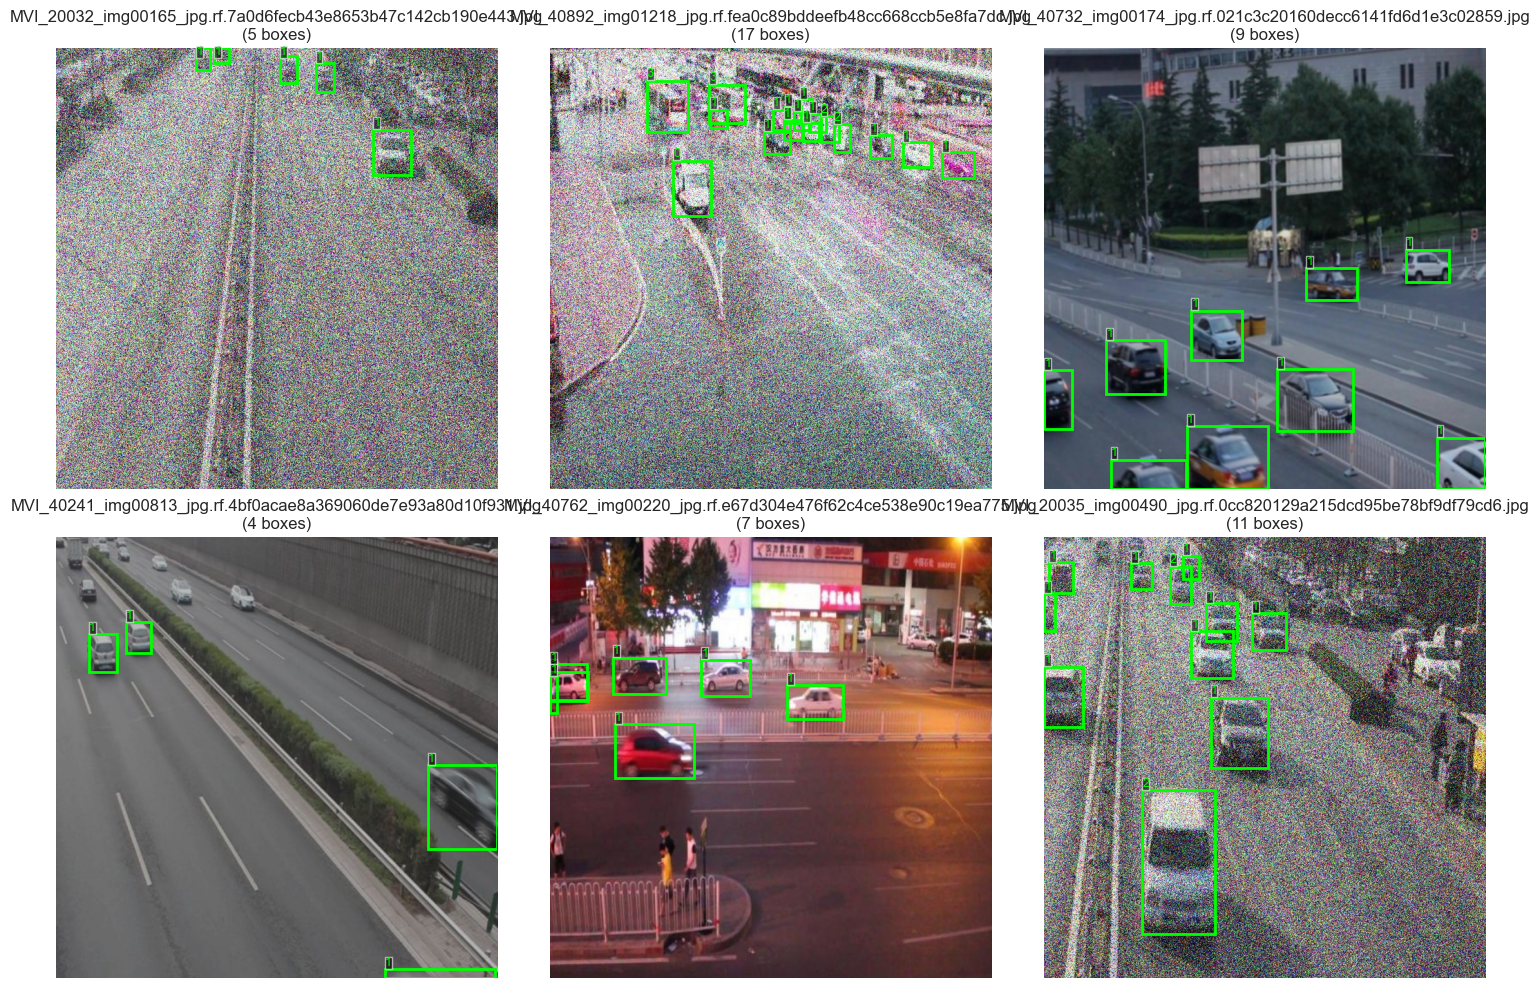

✓ Displayed 6 random training samples.


In [42]:
from matplotlib import patches

display_split = 'train'
train_images_dir = splits[display_split]
train_labels_dir = label_splits[display_split]

all_train_img_paths = sorted([p for p in train_images_dir.glob('*') if p.suffix.lower() in ('.jpg', '.jpeg', '.png')])
num_to_sample = min(6, len(all_train_img_paths))
train_img_paths = random.sample(all_train_img_paths, num_to_sample)

print(f'Displaying {len(train_img_paths)} random {display_split} images with bounding boxes:')

num_images = len(train_img_paths)
n_cols = 3
n_rows = (num_images + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if num_images > 1 else [axes]

for idx, img_path in enumerate(train_img_paths):
    ax = axes[idx]
    img = cv2.imread(str(img_path))
    if img is None:
        ax.axis('off')
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    ax.imshow(img)

    bbox_count = 0
    label_path = train_labels_dir / (img_path.stem + '.txt')
    if label_path.exists():
        with open(label_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                try:
                    cls = int(float(parts[0]))
                    cx, cy, bw, bh = map(float, parts[1:5])
                    bbox_count += 1
                except Exception:
                    continue

                x1 = int((cx - bw / 2) * w)
                y1 = int((cy - bh / 2) * h)
                box_w = int(bw * w)
                box_h = int(bh * h)

                rect = patches.Rectangle((x1, y1), box_w, box_h, linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, max(y1 - 5, 10), f'{cls}', color='lime', fontsize=9, bbox=dict(facecolor='black', alpha=0.6, pad=0))
        ax.set_title(f'{img_path.name}\n({bbox_count} boxes)')
    else:
        ax.set_title(f'{img_path.name} (no labels)')

    ax.axis('off')

for idx in range(num_images, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f'✓ Displayed {num_images} random training samples.')